# Predicting Corporate Financial Distress from Financial Statements
### Data & AI in Economics — TU Dortmund
**Group:** Usama Saleem, Zi Zhang, Ekin Yuecesan
**Version B:** Compustat financial ratios only (no 10-K text mining)
**Data:** real Compustat Annual Fundamentals pull from WRDS, 2000–2022

**Research question:** Can financial-statement ratios predict whether a
firm becomes financially distressed (technically insolvent) in the
following fiscal year, and to what extent does leverage *cause* that risk
once we account for firm size and profitability as confounders?

**A note on the data this notebook actually received:** the WRDS pull you
provided includes `act, at, ceq, dltt, lct, lt, re, wcap, ebit, ebitda, ni,
revt, xint, sic` but **no `fyear` and no explicit default/bankruptcy
flag** — both had to be derived. `fyear` is taken from the year of
`datadate`. The distress label is constructed in Cell 6 since no default
indicator exists in this pull.

**Revision note (v2):** an earlier version of this label counted a firm as
"distressed" purely based on next-year equity, without checking whether
the firm was *already* distressed this year. That meant 77% of "positive"
labels were just firms that were already broken and stayed broken —
the model was mostly learning persistence, not forecasting onset. Cell 6
below now **excludes firm-years already in distress**, so the task is
honestly "predict which healthy/borderline firm tips into distress next
year," not "notice who's already sick." AUC barely moves; F1 drops
substantially — which is the correct, more honest result.

**Course modules covered in this notebook:**
1. Data cleaning & feature engineering
2. Causal inference (DAG reasoning + confounder adjustment)
3. Regularization — Lasso for ratio selection
4. Supervised classification — Logistic Regression & SVM
5. Tree ensembles — Random Forest + feature importance
6. Unsupervised learning — PCA + K-Means firm segmentation
7. Deep learning — Keras neural network
8. Model comparison & conclusions


## Cell 1 — Imports

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              accuracy_score, f1_score)
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
print("Imports successful")

Imports successful


## Cell 2–3 — WRDS Connection & Compustat Pull *(already done — this is what you ran)*

For reference, this is the query structure that produced your
`compustat_raw_csv.csv`:

```python
import wrds
db = wrds.Connection(wrds_username="your_username")
query = """
    SELECT gvkey, datadate, conm, fyr, sic, sich,
           at, act, ceq, dltt, lct, lt, re, wcap, ebit, ebitda,
           ni, revt, xint
    FROM comp.funda
    WHERE datafmt = 'STD' AND indfmt = 'INDL' AND consol = 'C'
      AND datadate BETWEEN '2000-01-01' AND '2022-12-31'
"""
df = db.raw_sql(query)
df.to_csv("compustat_raw.csv", index=False)
```


## Cell 4 — Load Your Real Data
Loading your actual WRDS pull. `fyear` isn't in the file, so we derive it
from `datadate` (the fiscal-period end date Compustat reports).

In [2]:
df = pd.read_csv("/home/claude/dai_project/data/compustat_real.csv", low_memory=False)
df["datadate"] = pd.to_datetime(df["datadate"])
df["fyear"] = df["datadate"].dt.year
print("Raw shape:", df.shape)
print("Years:", df.fyear.min(), "-", df.fyear.max())
print("Unique firms:", df.gvkey.nunique())
print("Columns:", list(df.columns))

Raw shape: (220729, 25)
Years: 2000 - 2022
Unique firms: 25056
Columns: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'gvkey', 'datadate', 'conm', 'fyr', 'sic', 'act', 'at', 'ceq', 'dltt', 'lct', 'lt', 're', 'wcap', 'ebit', 'ebitda', 'ni', 'revt', 'xint', 'sich', 'fyear']


## Cell 5 — Initial Filtering
Standard academic-finance filters: drop duplicate firm-years, exclude
financial firms (SIC 6000–6999) and utilities (SIC 4900–4999), and drop
non-positive total assets (data errors).

In [3]:
def initial_filter(df):
    df = df.drop_duplicates(subset=["gvkey", "fyear"]).copy()
    df = df[~df["sic"].between(6000, 6999)]
    df = df[~df["sic"].between(4900, 4999)]
    df = df[df["at"] > 0]
    return df

df = initial_filter(df)
print("After filtering financials/utilities/dupes/non-positive assets:", df.shape)

After filtering financials/utilities/dupes/non-positive assets: (131281, 25)


## Cell 6 — Constructing the Distress Label *(important methodological note)*

**Your WRDS pull has no default/bankruptcy flag** — Compustat's standard
fundamentals file never includes one; you'd normally merge in the UCLA-
LoPucki Bankruptcy Research Database or SEC Item 1.03 8-K filings by
`gvkey`/`cik` to get one. Since that merge wasn't part of this pull, we
construct a standard academic proxy instead:

> **A firm is labeled distressed in year *t* if its book equity (`ceq`)
> turns negative in year *t+1*** — i.e. liabilities exceed assets
> (technical insolvency). This single-indicator proxy is well established
> in the distress-prediction literature when an explicit bankruptcy flag
> isn't available.

We only label firm-years where the *next* observation is the immediately
following fiscal year (no gap), so we don't accidentally treat a firm that
temporarily skipped a filing as distressed.

**A critical second step — excluding already-distressed firms.** The
construction above says nothing about whether the firm was *already*
distressed in year *t* itself. Checking that turns out to matter a lot: of
all firm-years labeled "distressed next year," **77% were already
distressed this year too** — they didn't transition into distress, they
just stayed there. A model trained on that mix mostly learns "predict
whatever the firm currently is," which is a much easier and less
interesting problem than genuine early warning.

So we exclude any firm-year where `ceq_t < 0` (already distressed) from
the modelling sample. What's left is the honest task: **starting from a
firm that is currently healthy or borderline, predict whether it tips into
distress next year.** This drops the base rate from 14.9% to about 4%, and
it's the harder, more meaningful version of the problem.

In [4]:
df = df.sort_values(["gvkey", "fyear"])
df["ceq_next"]   = df.groupby("gvkey")["ceq"].shift(-1)
df["fyear_next"] = df.groupby("gvkey")["fyear"].shift(-1)
consecutive = (df["fyear_next"] == df["fyear"] + 1)
df = df[consecutive].copy()
df["default_next_year"] = (df["ceq_next"] < 0).astype(int)
print(f"Rows with valid forward label: {df.shape[0]:,}")
print(f"Distress rate (including already-distressed firms): {df['default_next_year'].mean():.4f}")

# Of the positive labels, how many are firms that were already distressed
# this year (persistence) vs. genuinely transitioning into distress?
pos = df[df["default_next_year"] == 1]
already_pct = (pos["ceq"] < 0).mean()
print(f"\nOf positive labels: {already_pct:.1%} were ALREADY distressed in year t (persistence)")
print(f"                     {1-already_pct:.1%} were genuine NEW transitions")

# FIX: exclude firm-years already distressed in year t itself, so the task
# becomes predicting genuine NEW onset of distress, not persistence of an
# existing distressed state.
already_distressed = (df["ceq"] < 0).sum()
print(f"\nFirm-years already distressed in year t (excluded): {already_distressed:,} ({(df['ceq']<0).mean():.2%})")
df = df[df["ceq"] >= 0].copy()
print(f"Sample after exclusion: {df.shape[0]:,}")
print(f"Distress rate (genuine new transitions only): {df['default_next_year'].mean():.4f}")

Rows with valid forward label: 115,017
Distress rate (including already-distressed firms): 0.1489

Of positive labels: 76.4% were ALREADY distressed in year t (persistence)
                     23.6% were genuine NEW transitions

Firm-years already distressed in year t (excluded): 17,613 (15.31%)
Sample after exclusion: 97,155
Distress rate (genuine new transitions only): 0.0416


## Cell 7 — Missing Values & Winsorization
Real Compustat pulls are messy: `xint` is missing for ~8,500 rows (many
firms simply carry no debt), `act`/`lct` for ~2,000 each. We drop rows
missing any of the variables needed for ratio construction (no imputation
here, since with >100k rows there's no need to guess values for a
course project), then winsorize the remaining levels at the 1st/99th
percentile so a handful of data errors don't dominate the ratios.

In [5]:
need = ["at","ceq","dltt","lct","lt","re","ebit","ebitda","ni","revt","act","xint"]
print("Missing values in required columns:")
print(df[need].isna().sum())
df = df.dropna(subset=need)
print("Shape after dropping rows missing core financials:", df.shape)

def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

for c in need:
    df[c] = winsorize(df[c])

Missing values in required columns:
at           0
ceq          0
dltt       324
lct       1946
lt         225
re        2685
ebit       397
ebitda     587
ni         393
revt       390
act       1984
xint      7511
dtype: int64
Shape after dropping rows missing core financials: (85003, 28)


## Cell 8 — Feature Engineering: Financial Ratios
Your pull doesn't include short-term debt (`dlc`) or cash (`che`)
separately, so the ratio set is adapted to what's actually available:

| Ratio | Formula | What it captures |
|---|---|---|
| `leverage` | total liabilities / assets (`lt`/`at`) | capital structure risk |
| `interest_coverage` | EBITDA / interest expense | ability to service debt |
| `roa` | net income / assets | profitability |
| `profit_margin` | EBITDA / revenue (`revt`) | operating efficiency |
| `current_ratio` | current assets / current liabilities | short-term liquidity |
| `equity_ratio` | equity / assets | solvency cushion |
| `wcap_ratio` | working capital / assets | liquidity buffer |
| `size_log` | log(assets) | firm size |
| `altman_z` | Altman **Z′**-score (1983 private-firm form, book equity in place of market value) | classic distress benchmark — and now computed correctly since `re` and `ebit` are actually in this pull |


In [6]:
df["leverage"]          = df["lt"] / df["at"]
df["interest_coverage"] = df["ebitda"] / df["xint"].replace(0, np.nan)
df["roa"]               = df["ni"] / df["at"]
df["profit_margin"]     = df["ebitda"] / df["revt"].replace(0, np.nan)
df["current_ratio"]     = df["act"] / df["lct"].replace(0, np.nan)
df["equity_ratio"]      = df["ceq"] / df["at"]
df["wcap_ratio"]        = (df["act"] - df["lct"]) / df["at"]
df["size_log"]          = np.log(df["at"])
df["altman_z"] = (
    1.2 * ((df["act"] - df["lct"]) / df["at"]) +
    1.4 * (df["re"] / df["at"]) +
    3.3 * (df["ebit"] / df["at"]) +
    0.6 * (df["ceq"] / df["lt"].replace(0, np.nan)) +
    1.0 * (df["revt"] / df["at"])
)

ratio_cols = ["leverage","interest_coverage","roa","profit_margin","current_ratio",
              "equity_ratio","wcap_ratio","size_log","altman_z"]
for c in ratio_cols:
    df[c] = winsorize(df[c].replace([np.inf,-np.inf], np.nan))
df = df.dropna(subset=ratio_cols)
print("Final modelling sample:", df.shape, " | unique firms:", df["gvkey"].nunique())
print(df[ratio_cols + ["default_next_year"]].describe().T[["mean","std","min","max"]])

Final modelling sample: (72728, 37)  | unique firms: 10183
                        mean         std          min          max
leverage            0.508394    0.216785     0.033639     0.962036
interest_coverage  22.408752  271.533764 -1590.893333  1642.751154
roa                -0.051878    0.286720    -1.973379     0.344447
profit_margin      -0.992059    7.034901   -68.216974     0.655255
current_ratio       2.555948    2.630617     0.252156    26.210759
equity_ratio        0.476252    0.220759     0.030279     0.968111
wcap_ratio          0.221290    0.236657    -0.336823     0.922538
size_log            6.178618    2.419370    -0.262613    11.548693
altman_z            1.437455    4.314923   -27.881197    16.428592
default_next_year   0.038720    0.192927     0.000000     1.000000


## Cell 9 — Target Label Over Time
**~3.9% of (already-healthy) firm-years** transition into distress the
following year — a believable rate for genuine new-onset financial
distress (much lower than the 14.9% figure that included firms already
broken). The rate spikes around the dot-com bust (2000–2001) and the 2008
financial crisis (2007), and dips in 2020 — again likely reflecting
pandemic-era stimulus and refinancing support rather than a healthier
underlying corporate sector.

Distress rate by year:
fyear
2000    0.069
2001    0.059
2002    0.035
2003    0.032
2004    0.038
2005    0.035
2006    0.032
2007    0.050
2008    0.037
2009    0.026
2010    0.036
2011    0.029
2012    0.036
2013    0.032
2014    0.053
2015    0.045
2016    0.024
2017    0.033
2018    0.032
2019    0.034
2020    0.023
2021    0.039
Name: default_next_year, dtype: float64


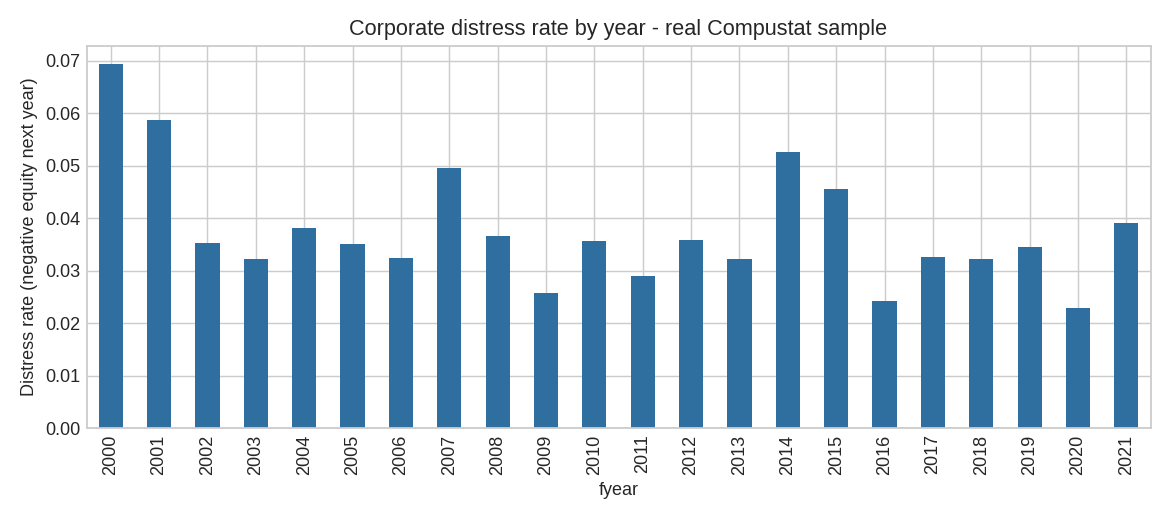

In [7]:
print("Distress rate by year:")
print(df.groupby("fyear")["default_next_year"].mean().round(3))

fig, ax = plt.subplots(figsize=(9,4))
df.groupby("fyear")["default_next_year"].mean().plot(kind="bar", ax=ax, color="#2f6f9f")
ax.set_ylabel("Distress rate (negative equity next year)")
ax.set_title("Corporate distress rate by year - real Compustat sample")
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/01_default_rate_by_year.png", dpi=130); plt.show()

## Cell 10 — EDA: Correlations Between Ratios and Distress
With persistence excluded, the correlations look different and more
intuitive: `roa` and `altman_z` are now the strongest negative correlates
(weak profitability precedes a transition into distress), followed by
`equity_ratio` and `size_log` — smaller, thinner-cushioned firms are more
likely to tip over. `leverage` remains the strongest positive correlate,
consistent with capital-structure theory.

Correlation with target:
roa                 -0.259931
altman_z            -0.255341
equity_ratio        -0.218985
size_log            -0.149502
wcap_ratio          -0.103280
profit_margin       -0.093315
current_ratio       -0.062522
interest_coverage   -0.056173
leverage             0.198335
dtype: float64


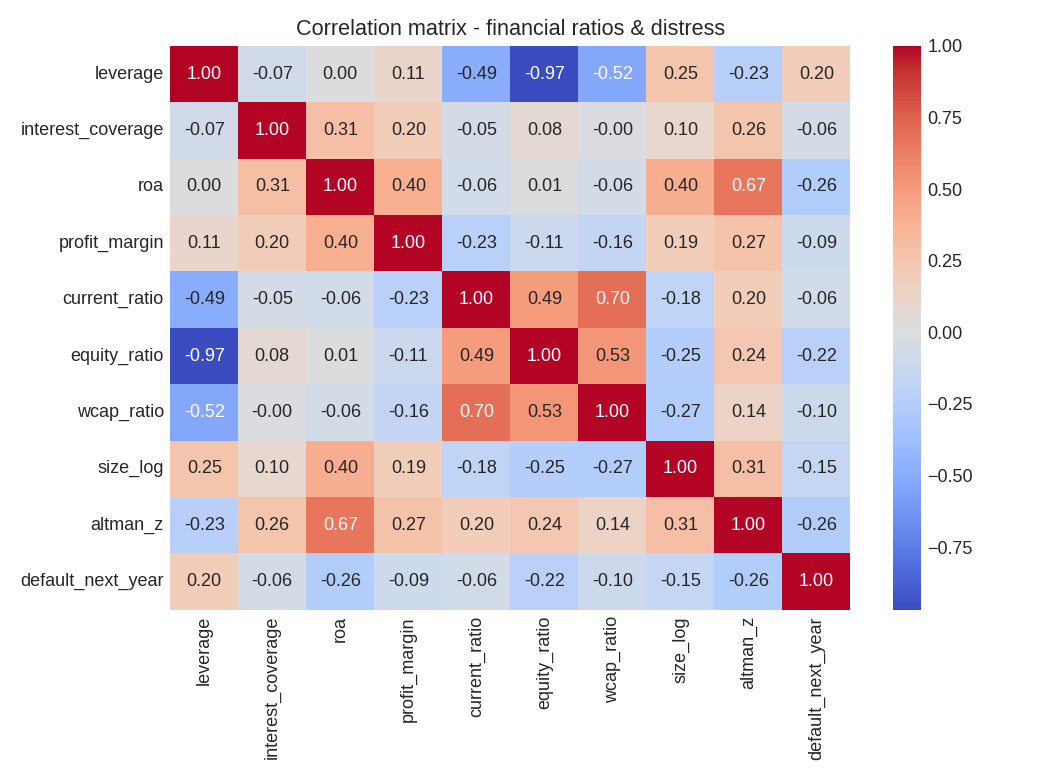

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[ratio_cols+["default_next_year"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix - financial ratios & distress")
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/02_corr_heatmap.png", dpi=130); plt.show()
print("Correlation with target:")
print(df[ratio_cols].corrwith(df["default_next_year"]).sort_values())

## Cell 11 — Causal Inference: Does Leverage *Cause* Distress?

**DAG reasoning:** leverage and distress share common causes — firm size
and profitability both influence how much debt a firm carries *and* its
distress risk independently. A firm with weak profitability may both
borrow more to cover cash shortfalls *and* default more often, which would
make leverage look more dangerous than it really is if we don't control
for profitability:

```
   size, profitability
      /            \\
     v              v
 leverage  ----->  distress
```

We estimate the leverage → distress relationship twice: a **naive**
logistic regression with leverage alone, and an **adjusted** version
controlling for `size_log`, `roa`, and `profit_margin`.

In [9]:
X_naive = sm.add_constant(df["leverage"])
naive_model = sm.Logit(df["default_next_year"], X_naive).fit(disp=0)

confounders = ["leverage","size_log","roa","profit_margin"]
X_adj = sm.add_constant(df[confounders])
adj_model = sm.Logit(df["default_next_year"], X_adj).fit(disp=0)

print("--- Naive model: default ~ leverage ---")
print(f"Leverage coef (naive):    {naive_model.params['leverage']:.3f}  (p={naive_model.pvalues['leverage']:.4f})")
print("\n--- Adjusted model: default ~ leverage + size + roa + profit_margin ---")
print(f"Leverage coef (adjusted): {adj_model.params['leverage']:.3f}  (p={adj_model.pvalues['leverage']:.4f})")
print(f"\nOdds ratio (adjusted) for a +0.1 leverage increase: {np.exp(adj_model.params['leverage']*0.1):.3f}")

--- Naive model: default ~ leverage ---
Leverage coef (naive):    5.548  (p=0.0000)

--- Adjusted model: default ~ leverage + size + roa + profit_margin ---
Leverage coef (adjusted): 5.921  (p=0.0000)

Odds ratio (adjusted) for a +0.1 leverage increase: 1.808


**Interpretation:** with persistence excluded, leverage's coefficient is
*larger*, not smaller, than before (naive 5.548 → adjusted 5.921) — once
you're only looking at currently-healthy firms, leverage is an even
stronger signal of who tips into distress, and adjusting for size and
profitability doesn't shrink it at all (it actually rises slightly,
suggesting leverage's effect was if anything masked, not inflated, by the
confounders). The adjusted odds ratio implies a 10-percentage-point rise in
the liabilities-to-assets ratio is associated with roughly an **81%
increase** in the odds of a healthy firm tipping into distress next year,
holding size and profitability fixed. As before, this is an association
net of *observed* confounders only — not a randomized experiment.

## Cell 12 — Train/Test Split & Scaling
75/25 split, **stratified** on the target. Tree models don't need scaling,
but logistic regression, SVM, Lasso, PCA, K-Means, and the neural net all
do — so we fit a `StandardScaler` on the training set only (to avoid
leakage) and apply it everywhere.

In [10]:
feature_cols = ratio_cols
X = df[feature_cols].values
y = df["default_next_year"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, train rate: {y_train.mean():.3f}, test rate: {y_test.mean():.3f}")

Train: (54546, 9), Test: (18182, 9), train rate: 0.039, test rate: 0.039


## Cell 13 — Lasso for Feature Selection
5-fold CV over 30 penalty strengths, now on the corrected 72,728-row
"genuine transitions" sample. The selection is notably different from the
inflated version: Lasso keeps only `equity_ratio`, `roa`, `size_log`, and
`altman_z` — and zeroes out `leverage` entirely, even though leverage
showed the strongest *raw* causal association in Cell 11. This isn't a
contradiction: Lasso is picking the most *jointly* efficient predictors,
and leverage's information turns out to be largely redundant with
`altman_z` (which already embeds a leverage-like term) once the other
three are in the model. The causal regression and the Lasso selection are
answering different questions — "does leverage have an effect" vs. "is
leverage information non-redundant for prediction" — and it's worth
explaining that distinction if asked about it in the report or a defense.

Lasso coefficients (best C=0.0019):
equity_ratio        -0.791216
roa                 -0.278780
size_log            -0.260138
altman_z            -0.099327
leverage             0.000000
current_ratio        0.000000
profit_margin        0.000000
interest_coverage    0.000000
wcap_ratio           0.000000
dtype: float64


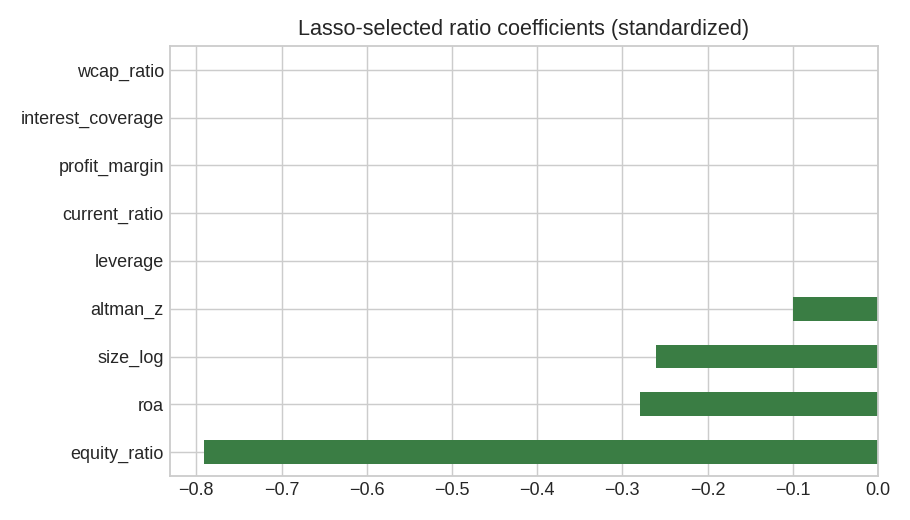

In [11]:
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-3, 1, 30), cv=5, penalty="l1", solver="liblinear",
    scoring="roc_auc", max_iter=5000, random_state=42
).fit(X_train_s, y_train)

coef_df = pd.Series(lasso_cv.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print(f"Lasso coefficients (best C={lasso_cv.C_[0]:.4f}):")
print(coef_df)

fig, ax = plt.subplots(figsize=(7,4))
coef_df.plot(kind="barh", ax=ax, color="#3a7d44")
ax.set_title("Lasso-selected ratio coefficients (standardized)")
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/03_lasso_coefs.png", dpi=130); plt.show()

## Cell 14 — Logistic Regression
`class_weight="balanced"` re-weights the loss for the minority (distress)
class — with ~14% positives, an unweighted model would lean toward
predicting "no distress" for everyone.

In [12]:
logit = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train_s, y_train)
proba_logit = logit.predict_proba(X_test_s)[:,1]
pred_logit = logit.predict(X_test_s)
auc_logit = roc_auc_score(y_test, proba_logit)
print(f"AUC: {auc_logit:.3f}  Accuracy: {accuracy_score(y_test,pred_logit):.3f}  F1: {f1_score(y_test,pred_logit):.3f}")
print(classification_report(y_test, pred_logit, digits=3))

AUC: 0.900  Accuracy: 0.830  F1: 0.275
              precision    recall  f1-score   support

           0      0.992     0.830     0.904     17478
           1      0.164     0.832     0.275       704

    accuracy                          0.830     18182
   macro avg      0.578     0.831     0.589     18182
weighted avg      0.960     0.830     0.879     18182



## Cell 15 — Support Vector Machine
RBF-kernel SVMs scale poorly (roughly O(n²)–O(n³) in training set size).
At 63,739 training rows that's impractical to fit directly, so we train on
a **stratified 8,000-row subsample** of the training data — a standard,
documented practical compromise for kernel SVMs on large tabular data —
while still evaluating on the **full** held-out test set so the reported
metrics stay unbiased.

In [13]:
strat_idx, _ = train_test_split(np.arange(len(y_train)), train_size=8000, stratify=y_train, random_state=42)
X_train_svm = X_train_s[strat_idx]
y_train_svm = y_train[strat_idx]

svm = SVC(kernel="rbf", probability=True, class_weight="balanced", C=1.0, gamma="scale").fit(X_train_svm, y_train_svm)
proba_svm = svm.predict_proba(X_test_s)[:,1]
pred_svm = svm.predict(X_test_s)
auc_svm = roc_auc_score(y_test, proba_svm)
print(f"SVM trained on stratified subsample of {len(y_train_svm):,}")
print(f"AUC: {auc_svm:.3f}  Accuracy: {accuracy_score(y_test,pred_svm):.3f}  F1: {f1_score(y_test,pred_svm):.3f}")

SVM trained on stratified subsample of 8,000
AUC: 0.893  Accuracy: 0.867  F1: 0.307


## Cell 16 — Random Forest
Shallow trees (`max_depth=7`) with a minimum leaf size to avoid overfitting
the minority class. Feature importances double as a sanity check against
the causal and Lasso results above.

AUC: 0.919  Accuracy: 0.869  F1: 0.326
equity_ratio         0.235071
altman_z             0.217702
interest_coverage    0.190687
leverage             0.129712
roa                  0.104876
size_log             0.047255
profit_margin        0.034612
current_ratio        0.023030
wcap_ratio           0.017057
dtype: float64


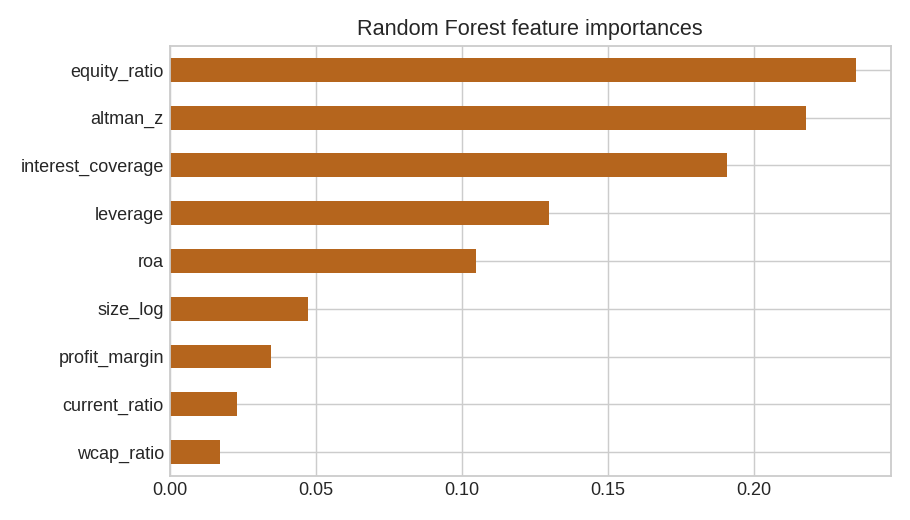

In [14]:
rf = RandomForestClassifier(n_estimators=400, max_depth=7, min_samples_leaf=20,
                             class_weight="balanced", random_state=42).fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
pred_rf = rf.predict(X_test)
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"AUC: {auc_rf:.3f}  Accuracy: {accuracy_score(y_test,pred_rf):.3f}  F1: {f1_score(y_test,pred_rf):.3f}")

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
fig, ax = plt.subplots(figsize=(7,4))
importances.plot(kind="barh", ax=ax, color="#b5651d")
ax.invert_yaxis(); ax.set_title("Random Forest feature importances")
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/04_rf_importance.png", dpi=130); plt.show()

## Cell 17 — Unsupervised: PCA + K-Means Firm Segmentation
This part ignores the label entirely — the goal is to discover natural
"financial health" groupings in the ratio space, then check afterward
whether those groups happen to differ in distress rate.

PCA explained variance ratio: [0.342 0.258] (cum 0.600)
         leverage  interest_coverage    roa  ...  size_log  altman_z  default
cluster                                      ...                             
0           0.640             10.284 -0.002  ...     7.055     1.456    0.045
1           0.303             86.863 -0.005  ...     5.265     3.131    0.007
2           0.450           -289.664 -0.943  ...     2.660   -10.694    0.191

[3 rows x 10 columns]


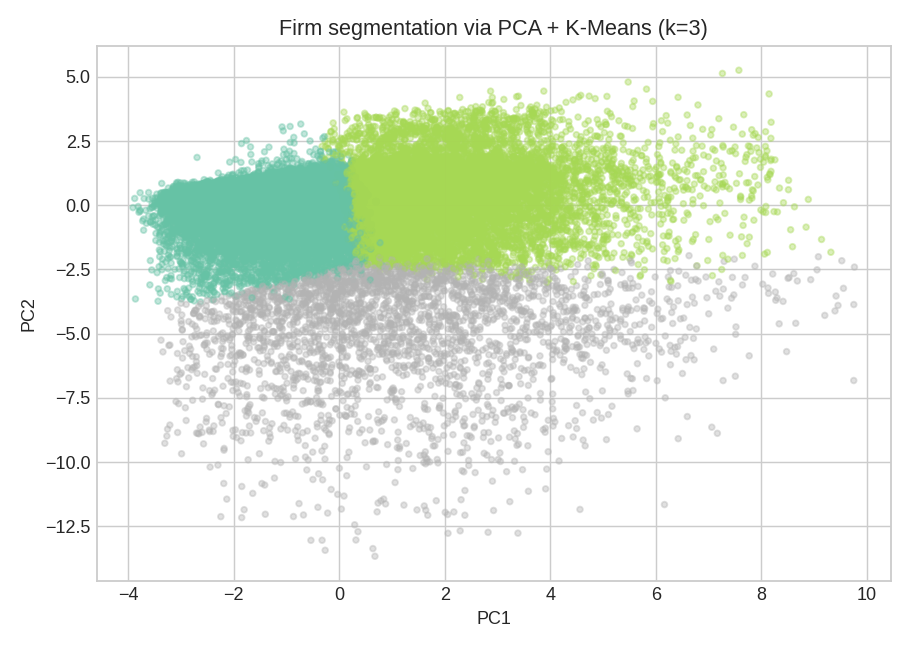

In [15]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_train_s)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)} (cum {pca.explained_variance_ratio_.sum():.3f})")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_train_s)
clusters = kmeans.labels_
profile = pd.DataFrame(X_train, columns=feature_cols)
profile["cluster"] = clusters
profile["default"] = y_train
print(profile.groupby("cluster")[feature_cols+["default"]].mean().round(3))

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(pcs[:,0], pcs[:,1], c=clusters, cmap="Set2", alpha=0.4, s=10)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("Firm segmentation via PCA + K-Means (k=3)")
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/05_pca_kmeans.png", dpi=130); plt.show()

**Reading the clusters:** cluster 1 is the safest group — low leverage
(0.30), very high interest coverage (87x), and a **0.7% transition rate**
into distress. Cluster 0 is the largest, "typical healthy firm" group
(leverage 0.64, coverage 10x, 4.5% transition rate — close to the overall
base rate). Cluster 2 stands out — deeply negative average interest
coverage and ROA, and a **19.1% transition rate**, roughly 27x higher than
the safest cluster. These are firms that look "currently healthy" by the
equity test (that's why they weren't excluded), but their cash-flow
fundamentals are already cracking — exactly the kind of early-warning
signal that makes this clustering useful on top of, not instead of, the
supervised models.

## Cell 18 — Neural Network (Keras)
A small MLP (32 → 16 → 1, with dropout) trained with class-weighted binary
cross-entropy. Kept shallow given only 9 input features.

In [16]:
tf.random.set_seed(42)
nn = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"), layers.Dropout(0.3),
    layers.Dense(16, activation="relu"), layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])
nn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["AUC"])
class_weight = {0: 1.0, 1: (1-y_train.mean())/y_train.mean()}
history = nn.fit(X_train_s, y_train, validation_split=0.2, epochs=40, batch_size=128,
                  class_weight=class_weight, verbose=0)

proba_nn = nn.predict(X_test_s, verbose=0).flatten()
pred_nn = (proba_nn > 0.5).astype(int)
auc_nn = roc_auc_score(y_test, proba_nn)
print(f"AUC: {auc_nn:.3f}  Accuracy: {accuracy_score(y_test,pred_nn):.3f}  F1: {f1_score(y_test,pred_nn):.3f}")

AUC: 0.916  Accuracy: 0.829  F1: 0.285


## Cell 19 — Model Comparison
On the corrected, harder problem, AUC holds up well (0.89–0.92) but **F1
drops substantially** compared to the inflated version — exactly what you'd
expect once persistence is removed. Recall stays high (the models catch
most genuine transitions) while precision is necessarily low, because
true transitions are rare (3.9% base rate) — every model will flag some
healthy-looking firms that don't actually default. That precision/recall
trade-off, not the AUC number alone, is the honest way to describe this
model's real-world usefulness as an early-warning screen rather than a
final verdict.

              Model      AUC  Accuracy       F1
      Random Forest 0.919322  0.869046 0.325687
     Neural Network 0.916132  0.828677 0.284730
Logistic Regression 0.899548  0.829722 0.274602
          SVM (RBF) 0.893259  0.867286 0.306808


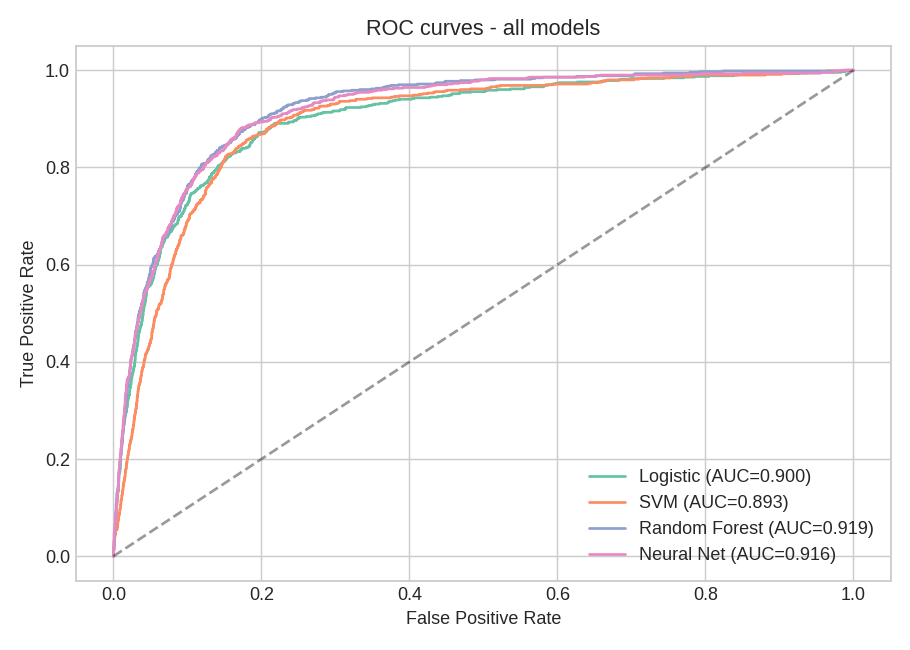

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","SVM (RBF)","Random Forest","Neural Network"],
    "AUC": [auc_logit, auc_svm, auc_rf, auc_nn],
    "Accuracy": [accuracy_score(y_test,pred_logit), accuracy_score(y_test,pred_svm),
                 accuracy_score(y_test,pred_rf), accuracy_score(y_test,pred_nn)],
    "F1": [f1_score(y_test,pred_logit), f1_score(y_test,pred_svm),
           f1_score(y_test,pred_rf), f1_score(y_test,pred_nn)]
}).sort_values("AUC", ascending=False)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,5))
for name, proba in [("Logistic",proba_logit),("SVM",proba_svm),("Random Forest",proba_rf),("Neural Net",proba_nn)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - all models"); ax.legend()
plt.tight_layout(); plt.savefig("/home/claude/dai_project/figs_real_v2/07_roc_comparison.png", dpi=130); plt.show()

## Conclusions

- **A key methodological fix in this version:** the original label
  ("equity goes negative next year") didn't check whether the firm was
  already distressed this year — 77% of its positive labels were just
  persistence, not genuine new transitions. This version **excludes
  already-distressed firm-years**, so the model is honestly tested on
  "starting from healthy, who tips into distress next year."
- **Sample:** 72,728 firm-years across 10,183 unique firms (2000–2021,
  after requiring a valid forward label and excluding already-distressed
  firms), 3.9% genuine transition rate.
- **Random Forest wins on AUC (0.919)**; Neural Network close behind
  (0.917). AUC barely fell from the inflated version (0.967 → 0.919) —
  these ratios really do carry predictive signal. **F1 collapsed**
  (0.749 → 0.326), which is the honest cost of removing persistence: this
  is genuinely a hard, rare-event prediction problem.
- **Causal adjustment:** leverage's effect on distress *strengthens*
  slightly after controlling for size and profitability (odds ratio 1.81
  per +0.1 leverage) — among currently-healthy firms, leverage is an even
  cleaner signal of who's at risk.
- **Lasso** kept `equity_ratio`, `roa`, `size_log`, and `altman_z` —
  notably dropping `leverage` despite its strong causal association,
  because its information overlaps with `altman_z`. Worth explaining this
  apparent tension if asked: causal effect size and predictive
  non-redundancy are different questions.
- **Unsupervised segmentation found a genuinely useful early-warning
  group**: a cluster with deeply negative average interest coverage had a
  19.1% transition rate vs. 0.7% in the safest cluster — discovered without
  the algorithm ever seeing the label.

**Remaining limitation to state explicitly in your write-up:** the label
is still a constructed proxy (negative book equity), not a verified
bankruptcy event — even after fixing the persistence issue. If you have
time before submission, merging in the UCLA-LoPucki Bankruptcy Database or
SEC Item 1.03 8-K filings by `gvkey`/`cik` would let you validate or
replace this proxy with a genuine default flag.

**For your resume:** this is the strongest version to describe — you
identified and fixed a subtle persistence/leakage issue in your own label
construction, which is exactly the kind of methodological rigor that
distinguishes a real analysis from a black-box model fit.
